In [103]:
#Hemos tenido que instalar esta librería así porque si no no iba uno de los improts de abajo
%pip install matplotlib seaborn scikit-learn scipy pandas numpy liac-arff

Note: you may need to restart the kernel to use updated packages.


In [104]:

# Importar librerías 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.model_selection import cross_validate, KFold, train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Configuración de semilla para obtener siempre los mismos resultados
np.random.seed(42)

In [105]:
#cargamos el archivo de datos nasa93.arff

data = arff.loadarff('nasa93.arff')
df = pd.DataFrame(data[0])

print("Forma original del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInfo del dataset:")
print(df.info())
print("\nVariables objetivo - act_effort estadísticas:")
print(df['act_effort'].describe())

Forma original del dataset: (93, 24)

Primeras 5 filas:
   recordnumber projectname                   cat2  forg center    year  \
0           1.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
1           2.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
2           3.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
3           4.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
4           5.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   

              mode  rely  data  cplx  ...  acap  aexp  pcap  vexp  lexp  modp  \
0  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
1  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
2  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
3  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
4  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   

   too

Valores faltantes por columna:
recordnumber     0
projectname      0
cat2             0
forg             0
center           0
year             0
mode             0
rely             0
data             0
cplx             0
time             0
stor             0
virt             0
turn             0
acap             0
aexp             0
pcap             0
vexp             0
lexp             0
modp             0
tool             0
sced             0
equivphyskloc    0
act_effort       0
dtype: int64


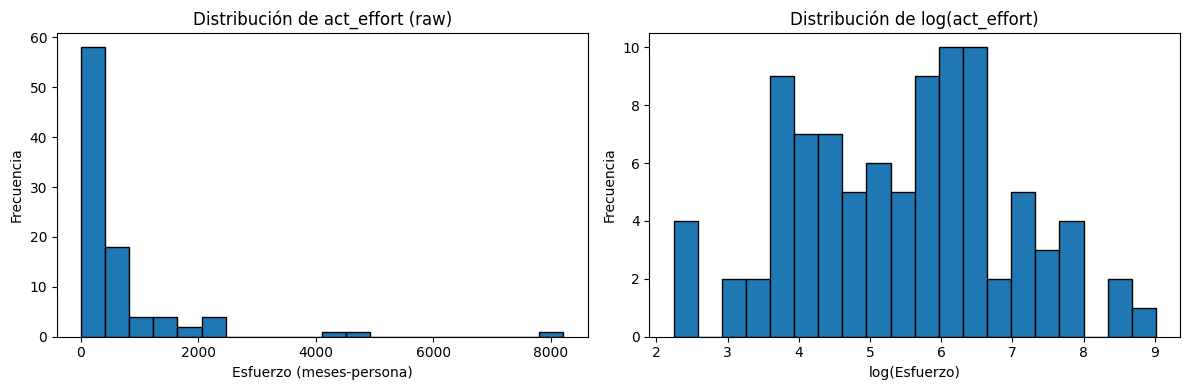

In [106]:
#Análisis basico del estado de los datos


print("Valores faltantes por columna:")
print(df.isnull().sum())

# Distribución del esfuerzo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['act_effort'], bins=20, edgecolor='black')
plt.title('Distribución de act_effort (raw)')
plt.xlabel('Esfuerzo (meses-persona)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['act_effort']), bins=20, edgecolor='black')
plt.title('Distribución de log(act_effort)')
plt.xlabel('log(Esfuerzo)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [107]:

# identificar y clasificar variables


# Variables a eliminar 
vars_drop = ['recordnumber', 'projectname']

# Variables categóricas 
cat_vars = ['cat2', 'forg', 'center', 'mode', 'rely', 'data', 'cplx', 
            'time', 'stor', 'virt', 'turn', 'acap', 'aexp', 'pcap', 
            'vexp', 'lexp', 'modp', 'tool', 'sced']

# Variables numéricas 
num_vars = ['year', 'equivphyskloc']

# Variable objetivo
target = 'act_effort'

print("Variables categóricas a codificar:", len(cat_vars))
print("Variables numéricas a escalar:", len(num_vars))

Variables categóricas a codificar: 19
Variables numéricas a escalar: 2


In [108]:
# =============================================================================
# PREPROCESADO EN PIPELINE + LIMPIEZA OUTLIERS - GUARDAR PROCESADO
# =============================================================================

# 1. LIMPIEZA OUTLIERS 
Q1 = df['act_effort'].quantile(0.25)   
Q3 = df['act_effort'].quantile(0.75)
IQR = Q3 - Q1
mask_clean = (df[target] >= (Q1 - 1.5 * IQR)) & (df[target] <= (Q3 + 1.5 * IQR))

df_clean = df[mask_clean].copy()
print(f"Dataset limpio: {len(df_clean)}/{len(df)} proyectos eliminados ({100*(1-len(df_clean)/len(df)):.1f}% outliers)")

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.decode('utf-8')

# 2 Variables
vars_drop = ['recordnumber', 'projectname']
cat_vars = ['cat2', 'forg', 'center', 'mode', 'rely', 'data', 'cplx', 
            'time', 'stor', 'virt', 'turn', 'acap', 'aexp', 'pcap', 
            'vexp', 'lexp', 'modp', 'tool', 'sced']
num_vars = ['year', 'equivphyskloc']
target = 'act_effort'
 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_vars),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_vars)
    ])

# 4. Crear datasets limpios
X_clean = df_clean.drop(columns=[target] + vars_drop)
y_raw_clean = df_clean[target]
y_log_clean = np.log1p(y_raw_clean)

print(f"Forma X limpio: {X_clean.shape}")
print(f"Forma y limpia: {y_raw_clean.shape}")
print(f"Estadísticas esfuerzo limpio:\n{y_raw_clean.describe()}")

X_processed = preprocessor.fit_transform(X_clean)
print(f"Forma X procesado: {X_processed.shape} (features escaladas + one-hot)")

# guardar en formato .npy
np.save('X_processed.npy', X_processed)
np.save('y_raw_clean.npy', y_raw_clean.values)
np.save('y_log_clean.npy', y_log_clean.values)




Dataset limpio: 83/93 proyectos eliminados (10.8% outliers)
Forma X limpio: (83, 21)
Forma y limpia: (83,)
Estadísticas esfuerzo limpio:
count      83.000000
mean      318.050602
std       336.453809
min         8.400000
25%        60.000000
50%       192.000000
75%       444.000000
max      1368.000000
Name: act_effort, dtype: float64
Forma X procesado: (83, 64) (features escaladas + one-hot)


In [109]:

# Modelo de Regresión Lineal 
lr_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('selector', SelectKBest(f_regression, k=20)),  
    ('regressor', LinearRegression())
])

In [110]:

# Validación cruzada 10

def calcular_metricas(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mdae = median_absolute_error(y_true, y_pred)

    naive_pred = np.full_like(y_true, np.mean(y_true), dtype=float)

    mae_naive = mean_absolute_error(y_true, naive_pred)
    mdae_naive = median_absolute_error(y_true, naive_pred)

    mase = mae / mae_naive if mae_naive != 0 else np.nan
    mdase = mdae / mdae_naive if mdae_naive != 0 else np.nan

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MdAE': mdae,
        'MASE': mase,
        'MdASE': mdase
    }

cv = KFold(n_splits=10, shuffle=True, random_state=42)
metricas_folds = []

print("10-FOLD CROSS VALIDATION\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean), start=1):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train_log, y_test_log = y_log_clean.iloc[train_idx], y_log_clean.iloc[test_idx]

    y_test_raw = np.expm1(y_test_log)

    lr_pipeline.fit(X_train, y_train_log)
    y_pred_log = lr_pipeline.predict(X_test)
    y_pred_raw = np.expm1(y_pred_log)

    metricas = calcular_metricas(y_test_raw, y_pred_raw)
    metricas_folds.append(metricas)

    print(f"Fold {fold:2d}: MAE ={metricas['MAE']:8.2f} ---- RMSE ={metricas['RMSE']:8.2f}")

# resultados
resultados_cv = pd.DataFrame(metricas_folds)

print("\n" + "=" * 70)
print("RESULTADOS FINALES - Regresion Lineal")
print("=" * 70)

resumen = pd.DataFrame({
    'Metrica': resultados_cv.columns,
    'Media': resultados_cv.mean().round(2).values,
    'Std': resultados_cv.std().round(2).values
})

print(resumen)
print("=" * 70)

resultados_cv.to_csv('resultados_finales.csv', index=False)
np.save('X.npy', X_clean.to_numpy())
np.save('y_log.npy', y_log_clean.to_numpy())

print("Archivos guardados: resultados_pruebas.csv, X.npy, y_log.npy")


10-FOLD CROSS VALIDATION

Fold  1: MAE =   64.99 ---- RMSE =   85.91
Fold  2: MAE =  272.73 ---- RMSE =  461.79
Fold  3: MAE =  540.85 ---- RMSE = 1256.81
Fold  4: MAE =  540.45 ---- RMSE =  837.05
Fold  5: MAE =  574.01 ---- RMSE = 1520.82
Fold  6: MAE =  108.81 ---- RMSE =  145.01
Fold  7: MAE =  133.42 ---- RMSE =  151.55
Fold  8: MAE =  162.15 ---- RMSE =  183.31
Fold  9: MAE =  164.31 ---- RMSE =  199.02
Fold 10: MAE =  236.76 ---- RMSE =  344.86

RESULTADOS FINALES - Regresion Lineal
  Metrica   Media     Std
0     MAE  279.85  196.79
1    RMSE  518.61  512.11
2    MdAE  127.02   57.10
3    MASE    1.55    1.61
4   MdASE    0.71    0.47
Archivos guardados: resultados_pruebas.csv, X.npy, y_log.npy


4. Regresión Lineal


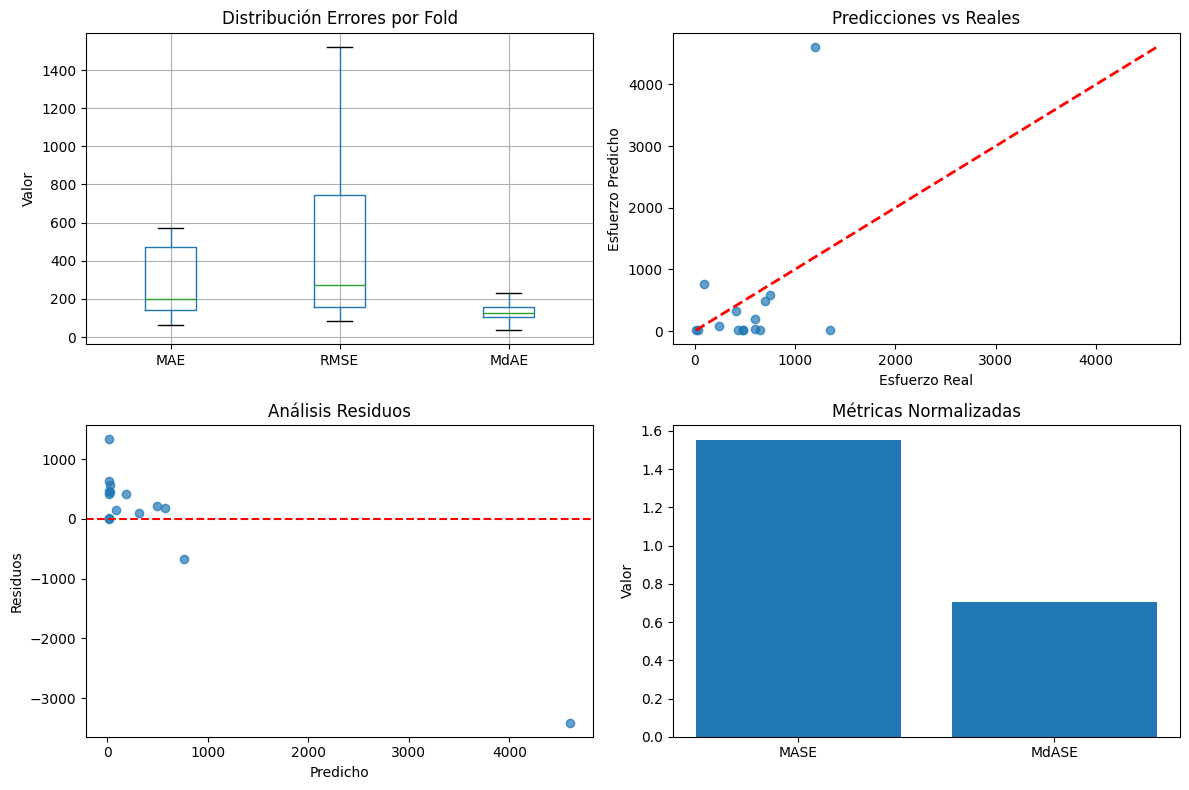

Guardado: 'Diagramas.png'


In [ ]:
print("4. Regresión Lineal")

# Boxplot métricas por fold
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
resultados_cv[['MAE', 'RMSE', 'MdAE']].boxplot()
plt.title('Distribución Errores por Fold')
plt.ylabel('Valor')

#Predicciones vs Reales (último fold)
X_test_final, y_test_final = X_clean.iloc[-15:], y_log_clean.iloc[-15:]
y_test_raw_final = np.expm1(y_test_final)
lr_pipeline.fit(X_clean[:-15], y_log_clean[:-15])
y_pred_final = np.expm1(lr_pipeline.predict(X_test_final))

plt.subplot(2, 2, 2)
plt.scatter(y_test_raw_final, y_pred_final, alpha=0.7)
minv = min(y_test_raw_final.min(), y_pred_final.min())
maxv = max(y_test_raw_final.max(), y_pred_final.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2)
plt.xlabel('Esfuerzo Real')
plt.ylabel('Esfuerzo Predicho')
plt.title('Predicciones vs Reales')

#Residuos
residuos = y_test_raw_final - y_pred_final
plt.subplot(2, 2, 3)
plt.scatter(y_pred_final, residuos, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicho')
plt.ylabel('Residuos')
plt.title('Análisis Residuos')

# MASE/MdASE
plt.subplot(2, 2, 4)
plt.bar(['MASE', 'MdASE'], resultados_cv[['MASE', 'MdASE']].mean())
plt.title('Métricas Normalizadas')
plt.ylabel('Valor')

plt.tight_layout()
plt.savefig('analisis_visual.png', dpi=300, bbox_inches='tight')
plt.show()

print("Guardado 'Diagramas.png'")